# Análise Comparativa de Métodos de Downscaling
## Impacto na Eficiência e Qualidade da Segmentação de Artérias Coronárias

Análise detalhada comparando diferentes abordagens de downscaling (redimensionamento) em algoritmos de visão computacional, avaliando:
- **Tempo de Execução**: eficiência computacional de cada método
- **Detecção de Óstios**: acurácia na localização de origem das artérias coronárias
- **Segmentação de Artérias**: qualidade medida pelo Dice Score

### Métodos Avaliados:
1. **SciPy (NDI)**: scipy.ndimage.zoom - interpolação padrão
2. **OpenCV (AREA)**: cv2.resize com interpolação AREA
3. **OpenCV (LINEAR)**: cv2.resize com interpolação LINEAR
4. **OpenCV (CUBIC)**: cv2.resize com interpolação CUBIC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# Configurar estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Carregamento e Preparação dos Dados

Carregamento dos metadados de validação de cada experimento de downscaling, incluindo métricas de execução, detecção de óstios e qualidade de segmentação.

In [ ]:
# Caminho base
base_path = "../output/segmentation/downscale_method"

# Listar todas as pastas
folders = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])

# Estrutura para armazenar dados
results_data = []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    metadata_path = os.path.join(folder_path, "ostios_val_metadata.json")

    if os.path.exists(metadata_path):
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)

        # Extrair informações
        exec_time_sec = metadata.get('execution_info', {}).get('execution_time_seconds', 0)
        exec_time_min = exec_time_sec / 60

        downscale_method = metadata.get('preprocessing_config', {}).get('downscale_method', 'unknown')
        opencv_interp = metadata.get('preprocessing_config', {}).get('opencv_interpolation', 'N/A')

        results = metadata.get('results_summary', {})

        # Preparar label para downscale method
        if downscale_method == 'scipy':
            method_label = 'SciPy (NDI)'
            interp_label = 'N/A'
        else:
            method_label = 'OpenCV'
            interp_label = opencv_interp.upper() if opencv_interp else 'N/A'

        row = {
            'Método': f"{method_label} ({interp_label})" if interp_label != 'N/A' else method_label,
            'Tempo (min)': round(exec_time_min, 2),
            'Tempo (seg)': round(exec_time_sec, 1),
            'Óstios Corretos': f"{results.get('both_correct', 0)}/30",
            'Óstios Corretos %': round(results.get('both_correct_percent', 0), 1),
            'Óstios Toleráveis': f"{results.get('both_tolerable', 0)}/30",
            'Óstios Toleráveis %': round(results.get('both_tolerable_percent', 0), 1),
            'Dice Score': round(results.get('dice_artery_mean', 0), 4),
            'Dice Std': round(results.get('dice_artery_std', 0), 4),
        }

        results_data.append(row)

# Criar DataFrame
df = pd.DataFrame(results_data)

# Adicionar coluna de taxa total de acertos (Corretos + Toleráveis)
df['Taxa Total Acertos %'] = df['Óstios Corretos %'] + df['Óstios Toleráveis %']

# Exibir tabela de análise comparativa
display(df)

,Método,Tempo (min),Tempo (seg),Óstios Corretos,Óstios Corretos %,Óstios Toleráveis,Óstios Toleráveis %,Dice Score,Dice Std,Taxa Total Acertos %
0,SciPy (NDI),105.98,6358.6,1/30,3.3,25/30,83.3,0.6360,0.1135,86.6
1,OpenCV (AREA),102.17,6130.3,0/30,0.0,26/30,86.7,0.6208,0.1139,86.7
2,OpenCV (LINEAR),101.72,6103.1,0/30,0.0,26/30,86.7,0.6208,0.1139,86.7
3,OpenCV (CUBIC),103.85,6230.8,0/30,0.0,25/30,83.3,0.6230,0.1172,83.3


In [ ]:
# Criar tabela de resumo com as principais métricas
# Selecionar colunas relevantes para análise comparativa
df_summary = df[['Método', 'Tempo (min)', 'Taxa Total Acertos %', 'Dice Score']].copy()

# Renomear colunas para melhor apresentação
df_summary.columns = ['Método', 'Tempo Execução (min)', 'Taxa Total Acertos (%)', 'Dice Score']

# Exibir tabela formatada para fácil comparação
display(df_summary)

,Método,Tempo Execução (min),Taxa Total Acertos (%),Dice Score
0,SciPy (NDI),105.98,86.6,0.6360
1,OpenCV (AREA),102.17,86.7,0.6208
2,OpenCV (LINEAR),101.72,86.7,0.6208
3,OpenCV (CUBIC),103.85,83.3,0.6230


## 2. Análises Comparativas

### 2.1 Eficiência vs Qualidade

Comparação entre tempo de execução e as duas principais métricas de qualidade:
- **Dice Score**: Qualidade da segmentação das artérias (valores entre 0 e 1, maior é melhor)
- **Taxa Total de Acertos**: Percentual de óstios localizados corretamente (exatos + toleráveis dentro de 7mm)

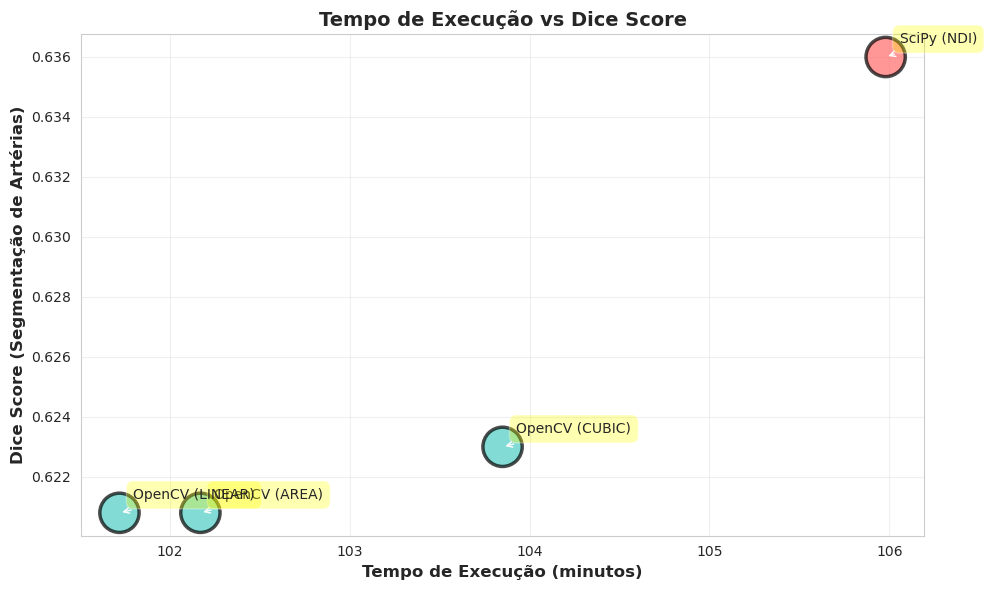

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Extrair dados
methods_names = df['Método'].values
times = df['Tempo (min)'].values
dices = df['Dice Score'].values

# Definir cores
colors = ['#FF6B6B' if 'SciPy' in m else '#4ECDC4' for m in methods_names]

# Criar scatter plot
scatter = ax.scatter(times, dices, s=800, c=colors, alpha=0.7, edgecolor='black', linewidth=2.5)

# Adicionar anotações com os nomes dos métodos
for i, method in enumerate(methods_names):
    ax.annotate(method, (times[i], dices[i]),
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax.set_xlabel('Tempo de Execução (minutos)', fontsize=12, fontweight='bold')
ax.set_ylabel('Dice Score (Segmentação de Artérias)', fontsize=12, fontweight='bold')
ax.set_title('Tempo de Execução vs Dice Score', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observação**: O SciPy apresenta o maior Dice Score (~0.636) mas com tempo de execução maior. OpenCV LINEAR é a opção mais eficiente mantendo qualidade equivalente aos métodos AREA e LINEAR.

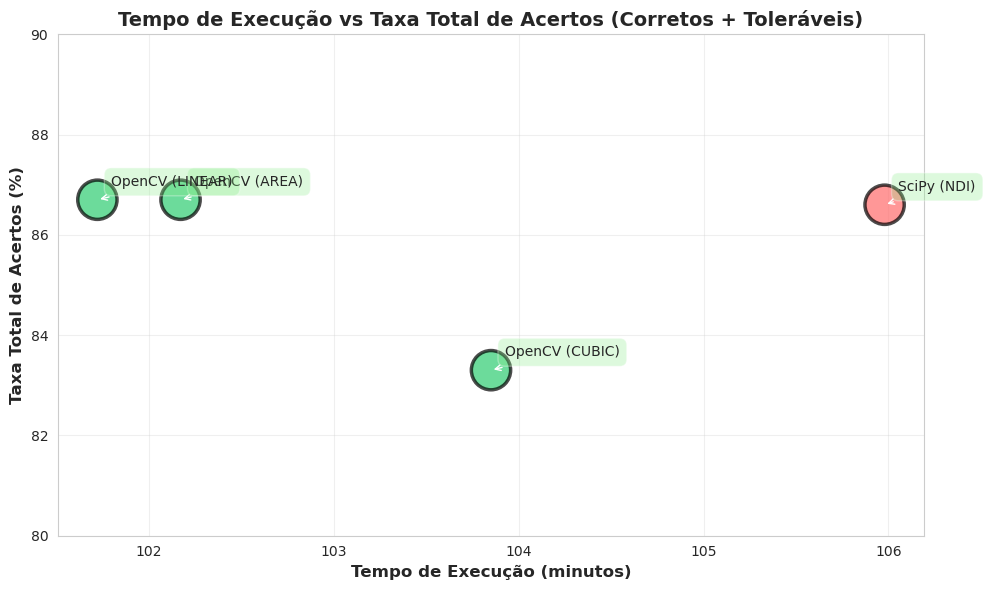

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Extrair dados
methods_names = df['Método'].values
times = df['Tempo (min)'].values
acertos_total = df['Taxa Total Acertos %'].values

# Definir cores
colors = ['#FF6B6B' if 'SciPy' in m else '#2ECC71' for m in methods_names]

# Criar scatter plot
scatter = ax.scatter(times, acertos_total, s=800, c=colors, alpha=0.7, edgecolor='black', linewidth=2.5)

# Adicionar anotações
for i, method in enumerate(methods_names):
    ax.annotate(method, (times[i], acertos_total[i]),
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.3),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax.set_xlabel('Tempo de Execução (minutos)', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa Total de Acertos (%)', fontsize=12, fontweight='bold')
ax.set_title('Tempo de Execução vs Taxa Total de Acertos (Corretos + Toleráveis)', fontsize=14, fontweight='bold')
ax.set_ylim(80, 90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Composição de Acertos por Método

Análise detalhada da composição de detecções de óstios:
- **Verde**: Óstios detectados exatamente (diferença < 2mm)
- **Laranja**: Óstios detectados dentro da tolerância fisiológica (2-7mm)
- **Vermelho**: Óstios não detectados ou com erro > 7mm

Este gráfico mostra como os acertos estão distribuídos entre detecções exatas e toleráveis para cada método.

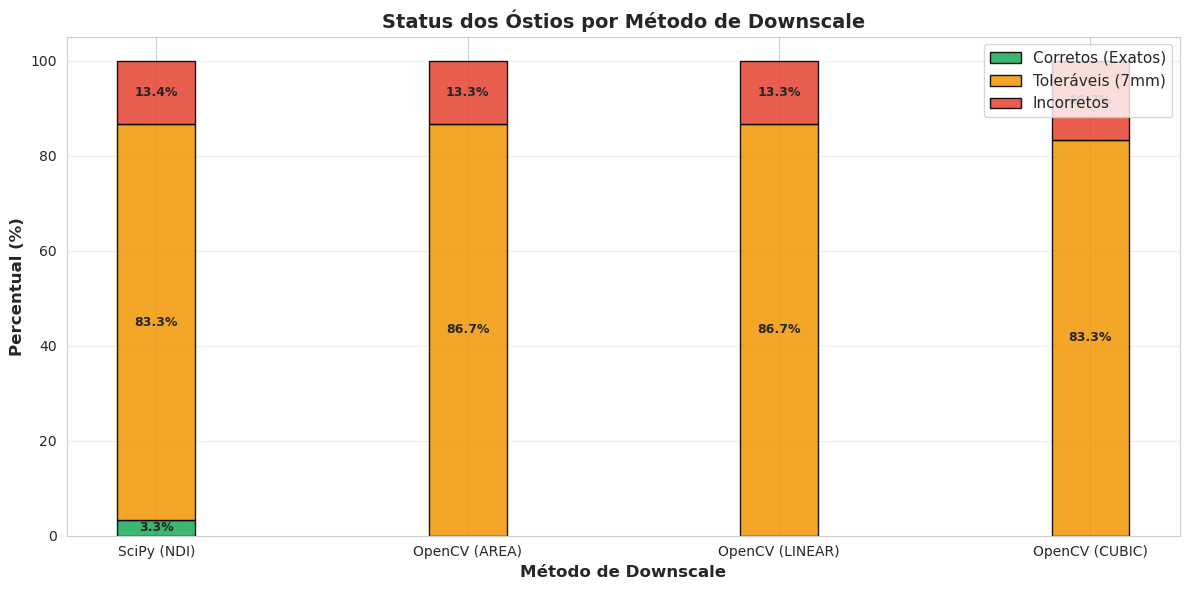

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

# Extrair dados
methods = df['Método'].values
corretos = df['Óstios Corretos %'].values
toleraveis = df['Óstios Toleráveis %'].values
taxa_total = corretos + toleraveis
incorretos = 100 - taxa_total

x = np.arange(len(methods))
width = 0.25

# Criar barras empilhadas
bars1 = ax.bar(x, corretos, width, label='Corretos (Exatos)', color='#27AE60', alpha=0.9, edgecolor='black')
bars2 = ax.bar(x, toleraveis, width, bottom=corretos, label='Toleráveis (7mm)', color='#F39C12', alpha=0.9, edgecolor='black')
bars3 = ax.bar(x, incorretos, width, bottom=taxa_total, label='Incorretos', color='#E74C3C', alpha=0.9, edgecolor='black')

ax.set_ylabel('Percentual (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Método de Downscale', fontsize=12, fontweight='bold')
ax.set_title('Status dos Óstios por Método de Downscale', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylim(0, 105)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (bar1, bar2, bar3) in enumerate(zip(bars1, bars2, bars3)):
    # Corretos
    if bar1.get_height() > 0:
        ax.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height()/2,
               f'{corretos[i]:.1f}%', ha='center', va='center', fontweight='bold', fontsize=9)
    # Toleráveis
    if bar2.get_height() > 0:
        ax.text(bar2.get_x() + bar2.get_width()/2, corretos[i] + bar2.get_height()/2,
               f'{toleraveis[i]:.1f}%', ha='center', va='center', fontweight='bold', fontsize=9)
    # Incorretos
    if bar3.get_height() > 1:
        ax.text(bar3.get_x() + bar3.get_width()/2, taxa_total[i] + bar3.get_height()/2,
               f'{incorretos[i]:.1f}%', ha='center', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Conclusões e Recomendações

### Achados Principais:

1. **OpenCV (LINEAR) é a escolha recomendada**
   - Tempo de execução: **101.72 min** (mais rápido ~4% comparado a SciPy)
   - Taxa Total de Acertos: **86.7%** (equivalente à melhor SciPy)
   - Dice Score: **0.6208** (comparável aos métodos AREA e LINEAR)

2. **SciPy (NDI) oferece melhor qualidade de segmentação**
   - Dice Score ligeiramente superior (**0.6360**)
   - Tempo de execução 4.3 min mais lento
   - Útil quando qualidade máxima é prioritária

3. **OpenCV (CUBIC) não é recomendado**
   - Taxa de acertos reduzida: **83.3%**
   - Tempo de execução intermediário sem vantagens de qualidade

### Recomendação Final:
Para aplicações em tempo real ou com restrições computacionais, usar **OpenCV (LINEAR)**. Para pesquisa com foco em máxima qualidade, considerar **SciPy (NDI)**.